# 02 — Preprocessing & Resampling
## Detectia fraudelor financiare — Dataset CreditCard Fraud (ULB)

Acest notebook contine:
- Incarcare date si separare features/target
- Train/test split stratificat (80/20)
- Standardizare Amount si Time
- SMOTE (sampling_strategy=0.1)
- ADASYN (sampling_strategy=0.1)
- Random Undersampling (baseline)
- Comparatie distributii clase inainte/dupa resampling
- Salvare date preprocesate

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# Configurare
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
SEED = 42

FIGURES_DIR = os.path.join('..', 'figures')
DATA_DIR = os.path.join('..', 'data')
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Librarii incarcate cu succes.')

Librarii incarcate cu succes.


## 1. Incarcarea datelor

In [2]:
# Incarcam datasetul original
df = pd.read_csv(os.path.join(DATA_DIR, 'creditcard.csv'))
print(f'Dataset original: {df.shape}')
print(f'Distributia claselor:')
print(df['Class'].value_counts())

Dataset original: (284807, 31)
Distributia claselor:
Class
0    284315
1       492
Name: count, dtype: int64


## 2. Separare features / target si standardizare

In [3]:
# Separare features si target
X = df.drop('Class', axis=1)
y = df['Class']

# Standardizare Amount si Time (V1-V28 sunt deja standardizate din PCA)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nAmount dupa standardizare: mean={X["Amount"].mean():.4f}, std={X["Amount"].std():.4f}')
print(f'Time dupa standardizare:   mean={X["Time"].mean():.4f}, std={X["Time"].std():.4f}')

Features shape: (284807, 30)
Target shape:   (284807,)

Amount dupa standardizare: mean=-0.0000, std=1.0000
Time dupa standardizare:   mean=-0.0000, std=1.0000


## 3. Train / Test Split stratificat (80/20)

In [4]:
# Split stratificat — pastreaza proportia claselor in ambele seturi
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train set: {X_train.shape[0]:,} tranzactii')
print(f'  Legitime: {(y_train == 0).sum():,}')
print(f'  Fraude:   {(y_train == 1).sum():,} ({(y_train == 1).sum() / len(y_train) * 100:.3f}%)')
print()
print(f'Test set:  {X_test.shape[0]:,} tranzactii')
print(f'  Legitime: {(y_test == 0).sum():,}')
print(f'  Fraude:   {(y_test == 1).sum():,} ({(y_test == 1).sum() / len(y_test) * 100:.3f}%)')

Train set: 227,845 tranzactii
  Legitime: 227,451
  Fraude:   394 (0.173%)

Test set:  56,962 tranzactii
  Legitime: 56,864
  Fraude:   98 (0.172%)


## 4. SMOTE (Synthetic Minority Over-sampling Technique)

In [5]:
# SMOTE — sampling_strategy=0.1 inseamna ca clasa minoritara va fi 10% din clasa majoritara
smote = SMOTE(sampling_strategy=0.1, random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'SMOTE — Train set resampled: {X_train_sm.shape[0]:,} tranzactii')
print(f'  Legitime: {(y_train_sm == 0).sum():,}')
print(f'  Fraude:   {(y_train_sm == 1).sum():,} ({(y_train_sm == 1).sum() / len(y_train_sm) * 100:.3f}%)')
print(f'  Fraude sintetice adaugate: {(y_train_sm == 1).sum() - (y_train == 1).sum():,}')

SMOTE — Train set resampled: 250,196 tranzactii
  Legitime: 227,451
  Fraude:   22,745 (9.091%)
  Fraude sintetice adaugate: 22,351


## 5. ADASYN (Adaptive Synthetic Sampling)

In [6]:
# ADASYN — genereaza mai multe sample sintetice in zonele dificile
adasyn = ADASYN(sampling_strategy=0.1, random_state=SEED)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train, y_train)

print(f'ADASYN — Train set resampled: {X_train_ad.shape[0]:,} tranzactii')
print(f'  Legitime: {(y_train_ad == 0).sum():,}')
print(f'  Fraude:   {(y_train_ad == 1).sum():,} ({(y_train_ad == 1).sum() / len(y_train_ad) * 100:.3f}%)')
print(f'  Fraude sintetice adaugate: {(y_train_ad == 1).sum() - (y_train == 1).sum():,}')

ADASYN — Train set resampled: 250,193 tranzactii
  Legitime: 227,451
  Fraude:   22,742 (9.090%)
  Fraude sintetice adaugate: 22,348


## 6. Random Undersampling (baseline)

In [7]:
# Random Undersampling — reducem clasa majoritara la un ratio rezonabil
# sampling_strategy=0.5 => clasa minoritara = 50% din clasa majoritara (ratio 1:2)
rus = RandomUnderSampler(sampling_strategy=0.5, random_state=SEED)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f'Random Undersampling — Train set resampled: {X_train_rus.shape[0]:,} tranzactii')
print(f'  Legitime: {(y_train_rus == 0).sum():,}')
print(f'  Fraude:   {(y_train_rus == 1).sum():,} ({(y_train_rus == 1).sum() / len(y_train_rus) * 100:.3f}%)')
print(f'  Tranzactii legitime eliminate: {(y_train == 0).sum() - (y_train_rus == 0).sum():,}')

Random Undersampling — Train set resampled: 1,182 tranzactii
  Legitime: 788
  Fraude:   394 (33.333%)
  Tranzactii legitime eliminate: 226,663


## 7. Vizualizare — Comparatie distributii clase

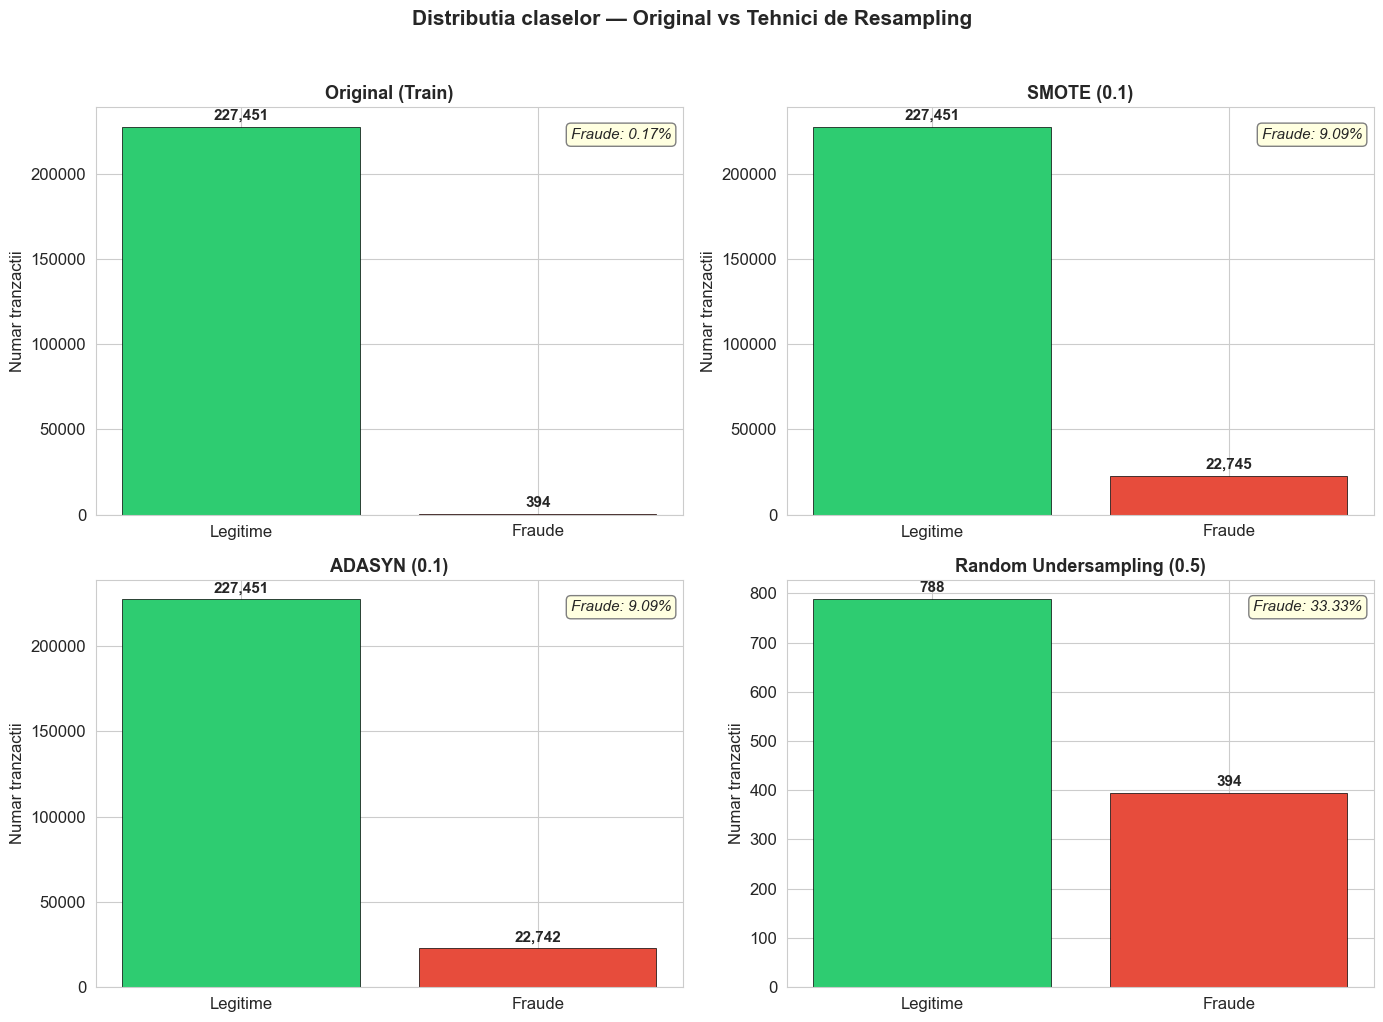

Salvat: figures/Figura_3_6.png


In [8]:
# Figura 3.6 — Distributia claselor inainte/dupa resampling (3 tehnici)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#2ecc71', '#e74c3c']
bar_labels = ['Legitime', 'Fraude']

datasets = [
    ('Original (Train)', y_train),
    ('SMOTE (0.1)', y_train_sm),
    ('ADASYN (0.1)', y_train_ad),
    ('Random Undersampling (0.5)', y_train_rus),
]

for ax, (title, y_data) in zip(axes.flat, datasets):
    counts = [int((y_data == 0).sum()), int((y_data == 1).sum())]
    bars = ax.bar(bar_labels, counts, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Numar tranzactii')
    # Valori pe bare
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.01,
                f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    # Procent fraude
    pct = counts[1] / sum(counts) * 100
    ax.text(0.98, 0.95, f'Fraude: {pct:.2f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=11, fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

plt.suptitle('Distributia claselor — Original vs Tehnici de Resampling',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'Figura_3_6.png'), bbox_inches='tight')
plt.show()
print('Salvat: figures/Figura_3_6.png')

## 8. Salvare date preprocesate

In [9]:
# Salvam toate seturile de date necesare pentru notebook-urile urmatoare
preprocessed = {
    'X_train': X_train.values,
    'X_test': X_test.values,
    'y_train': y_train.values,
    'y_test': y_test.values,
    'X_train_sm': X_train_sm.values if hasattr(X_train_sm, 'values') else X_train_sm,
    'y_train_sm': y_train_sm.values if hasattr(y_train_sm, 'values') else y_train_sm,
    'X_train_ad': X_train_ad.values if hasattr(X_train_ad, 'values') else X_train_ad,
    'y_train_ad': y_train_ad.values if hasattr(y_train_ad, 'values') else y_train_ad,
    'X_train_rus': X_train_rus.values if hasattr(X_train_rus, 'values') else X_train_rus,
    'y_train_rus': y_train_rus.values if hasattr(y_train_rus, 'values') else y_train_rus,
    'feature_names': list(X_train.columns),
}

save_path = os.path.join(DATA_DIR, 'preprocessed.joblib')
joblib.dump(preprocessed, save_path)
file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f'Salvat: data/preprocessed.joblib ({file_size_mb:.1f} MB)')
print(f'Chei salvate: {list(preprocessed.keys())}')

Salvat: data/preprocessed.joblib (186.0 MB)
Chei salvate: ['X_train', 'X_test', 'y_train', 'y_test', 'X_train_sm', 'y_train_sm', 'X_train_ad', 'y_train_ad', 'X_train_rus', 'y_train_rus', 'feature_names']


## SUMMARY

In [10]:
# Statistici cheie — celula SUMMARY
print('=' * 65)
print('SUMMARY — 02 Preprocessing & Resampling')
print('=' * 65)
print(f'Standardizare:      Amount si Time (StandardScaler)')
print(f'Train/Test split:   80/20, stratificat, random_state={SEED}')
print('-' * 65)

sets = [
    ('Original Train',       X_train, y_train),
    ('Original Test',        X_test,  y_test),
    ('SMOTE (0.1)',          X_train_sm, y_train_sm),
    ('ADASYN (0.1)',         X_train_ad, y_train_ad),
    ('RandomUndersampling',  X_train_rus, y_train_rus),
]

print(f'{"Set":<25} {"Total":>10} {"Legit":>10} {"Fraud":>8} {"% Fraud":>10}')
print('-' * 65)
for name, X_s, y_s in sets:
    n = len(y_s)
    n_legit = int((y_s == 0).sum())
    n_fraud = int((y_s == 1).sum())
    pct = n_fraud / n * 100
    print(f'{name:<25} {n:>10,} {n_legit:>10,} {n_fraud:>8,} {pct:>9.3f}%')

print('-' * 65)
print(f'Features:            {X_train.shape[1]} (V1-V28 + Amount + Time)')
print(f'Salvat:              data/preprocessed.joblib')
print('=' * 65)
print()
print('Figuri generate:')
print('  Figura_3_6.png — Distributia claselor: Original vs SMOTE vs ADASYN vs Undersampling')

SUMMARY — 02 Preprocessing & Resampling
Standardizare:      Amount si Time (StandardScaler)
Train/Test split:   80/20, stratificat, random_state=42
-----------------------------------------------------------------
Set                            Total      Legit    Fraud    % Fraud
-----------------------------------------------------------------
Original Train               227,845    227,451      394     0.173%
Original Test                 56,962     56,864       98     0.172%
SMOTE (0.1)                  250,196    227,451   22,745     9.091%
ADASYN (0.1)                 250,193    227,451   22,742     9.090%
RandomUndersampling            1,182        788      394    33.333%
-----------------------------------------------------------------
Features:            30 (V1-V28 + Amount + Time)
Salvat:              data/preprocessed.joblib

Figuri generate:
  Figura_3_6.png — Distributia claselor: Original vs SMOTE vs ADASYN vs Undersampling
